<a href="https://colab.research.google.com/github/Aman001-ctrl/MYRepository/blob/main/CNNmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing the required Libraries


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from sklearn.preprocessing import MinMaxScaler

Uploading The zip file


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving datasetcsdl.zip to datasetcsdl.zip


Extracting The Zip file


In [ ]:
import zipfile
zip_file = "/content/datasetcsdl.zip"
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("data_folder")
print("Files extracted!")

Files extracted!


In [ ]:
import os
os.listdir("data_folder")

['Apple Dataset.csv']

Reading The CSV file

In [ ]:
import pandas as pd
data = pd.read_csv("data_folder/Apple Dataset.csv")
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.099058,469033600
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.093890,175884800
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.086999,105728000
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.089152,86441600
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.091737,73449600


In [ ]:
for root, dirs, files in os.walk("data_folder"):
    for file in files:
        print(os.path.join(root, file))

data_folder/Apple Dataset.csv


In [ ]:
import pandas as pd
data = pd.read_csv("data_folder/Apple Dataset.csv")
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.099058,469033600
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.093890,175884800
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.086999,105728000
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.089152,86441600
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.091737,73449600


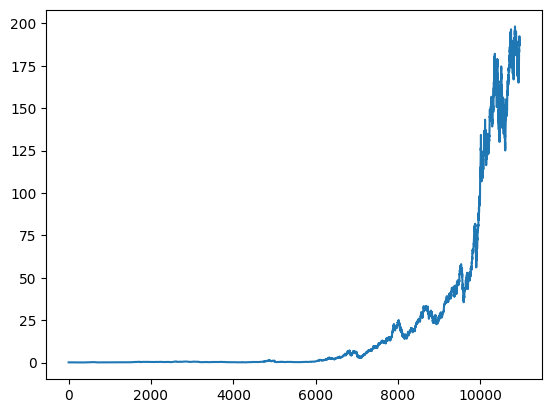

In [ ]:
import matplotlib.pyplot as plt
plt.plot(data['Close'])
plt.show()

In [ ]:
data = pd.read_csv("data_folder/Apple Dataset.csv")

In [ ]:
print(data.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


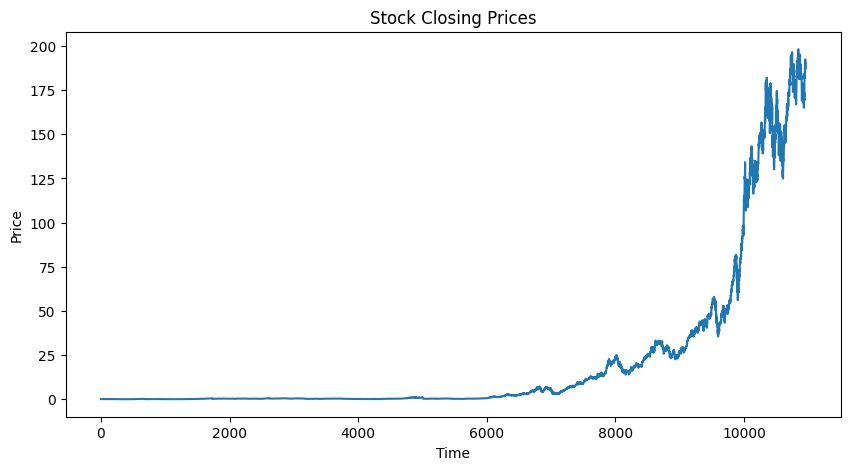

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(data['Close'])
plt.title("Stock Closing Prices")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

In [ ]:
prices = data['Close'].values.reshape(-1, 1)

scaler = MinMaxScaler()
prices_scaled = scaler.fit_transform(prices)

In [ ]:
def create_dataset(data, time_steps=10):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
        y.append(data[i+time_steps])
    return np.array(X), np.array(y)

X, y = create_dataset(prices_scaled, 10)

print(X.shape, y.shape)

(10944, 10, 1) (10944, 1)


In [ ]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
model = Sequential([
    Conv1D(64, 2, activation='relu', input_shape=(10,1)),
    MaxPooling1D(2),
    Flatten(),
    Dense(50, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 9, 64)          │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │        12,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,093 (51.14 KB)

 Trainable params: 13,093 (51.14 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(X_train, y_train, epochs=10, batch_size=16)

Epoch 1/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2.5932e-05
Epoch 2/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3.0771e-06
Epoch 3/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 2.9693e-06
Epoch 4/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3.1759e-06
Epoch 5/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.8390e-06
Epoch 6/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2.9347e-06
Epoch 7/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.9948e-06
Epoch 8/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2.5745e-06
Epoch 9/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2.7789e-06
Epoch 10/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 2.5896e-06


In [ ]:
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


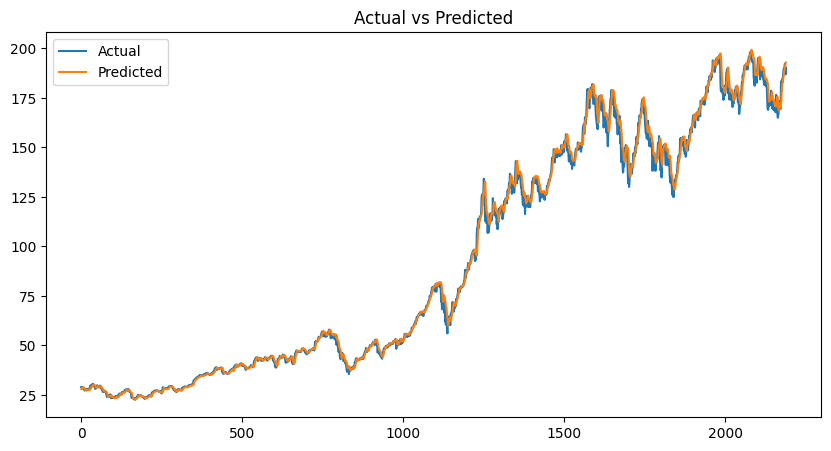

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
for i in range(5):
    print(f"Actual: {y_test_actual[i][0]:.2f}, Predicted: {predictions[i][0]:.2f}")

Actual: 29.07, Predicted: 27.96
Actual: 29.10, Predicted: 28.19
Actual: 28.48, Predicted: 28.59
Actual: 28.36, Predicted: 28.75
Actual: 28.80, Predicted: 28.83


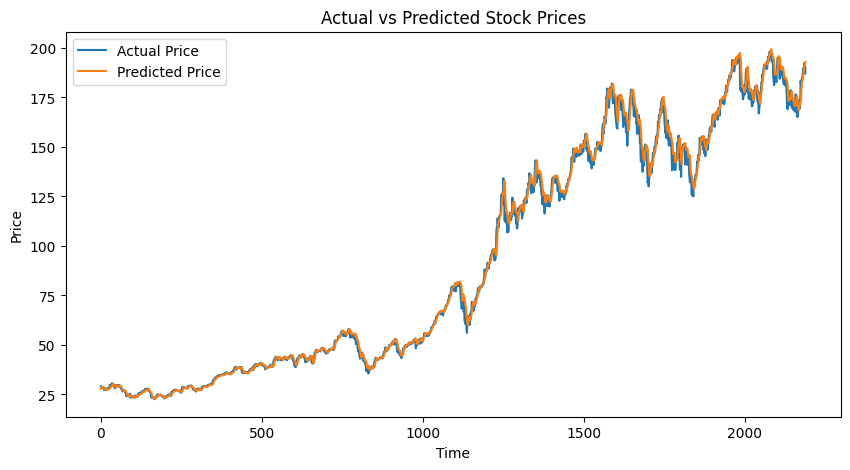

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label="Actual Price")
plt.plot(predictions, label="Predicted Price")
plt.title("Actual vs Predicted Stock Prices")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
print("RMSE:", rmse)

RMSE: 3.49962466676085


In [ ]:
last_10_days = prices_scaled[-10:]
last_10_days = last_10_days.reshape(1, 10, 1)
next_price = model.predict(last_10_days)
next_price = scaler.inverse_transform(next_price)
print("Next predicted price:", next_price[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Next predicted price: 192.9447


In [ ]:
import numpy as np

y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(model.predict(X_test), axis=1)

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [ ]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

y_true = y_test

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
print(y_true[:5])
print(y_pred[:5])
print(y_true.shape, y_pred.shape)

[[0.1465251 ]
 [0.1466892 ]
 [0.14354622]
 [0.14295296]
 [0.14517451]]
[[0]
 [0]
 [0]
 [0]
 [0]]
(2189, 1) (2189, 1)


In [ ]:
print(y_test.shape)
print(model.predict(X_test).shape)
print(y_test[:3])
print(model.predict(X_test)[:3])

(2189, 1)
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
(2189, 1)
[[0.1465251 ]
 [0.1466892 ]
 [0.14354622]]
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[[0.14090203]
 [0.14207435]
 [0.144098  ]]


In [ ]:
print("y_test shape:", y_test.shape)
print("pred shape:", model.predict(X_test).shape)

print("y_test sample:", y_test[:3])
print("pred sample:", model.predict(X_test)[:3])

y_test shape: (2189, 1)
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
pred shape: (2189, 1)
y_test sample: [[0.1465251 ]
 [0.1466892 ]
 [0.14354622]]
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
pred sample: [[0.14090203]
 [0.14207435]
 [0.144098  ]]


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(model.predict(X_test), axis=1)

cm = confusion_matrix(y_true, y_pred)
print(cm)

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[[2189]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [ ]:
import numpy as np
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int).flatten()
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
print(cm)

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
[[1230  959]
 [   0    0]]


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)
cm = confusion_matrix(y_true, y_pred)
print(cm)

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
[[2189]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


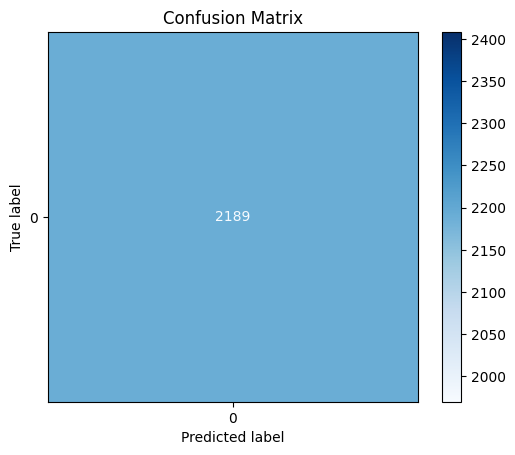

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2189

    accuracy                           1.00      2189
   macro avg       1.00      1.00      1.00      2189
weighted avg       1.00      1.00      1.00      2189



In [ ]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_true, y_pred))

Accuracy: 1.0


69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


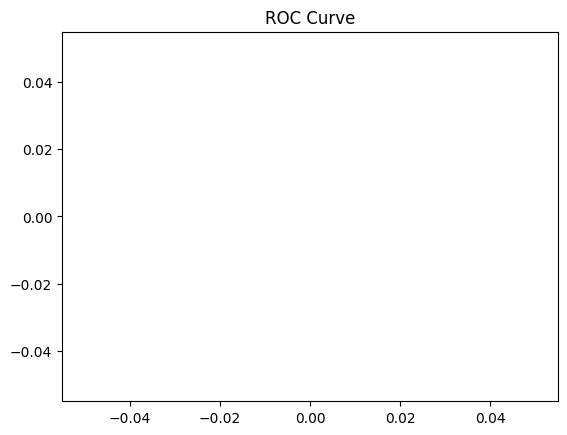

In [ ]:
from sklearn.metrics import roc_curve, auc
y_prob = model.predict(X_test)
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
import matplotlib.pyplot as plt
plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


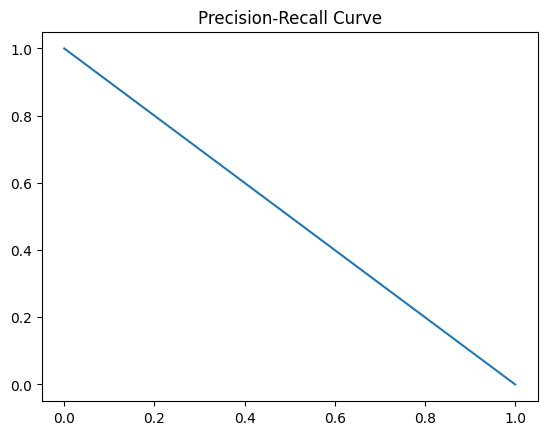

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_true, y_prob)
plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.show()

In [ ]:
misclassified = (y_true != y_pred)

print("Wrong predictions:", sum(misclassified))

Wrong predictions: 0
